# 1. Install the API

In [1]:
!pip install ucimlrepo

#2. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo   #it fetch the data from ucimlrepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')  #in generally python showes warnings if there are not having any errors so we want to ignore that errors
sns.set_theme(style='whitegrid')     # this is for the grids in the plots
plt.rcParams['figure.figsize'] = (10, 6)

#3. Load Dataset

In [3]:
print("Fetching data directly from UCI server")
heart_disease = fetch_ucirepo(id=45)
x_raw = heart_disease.data.features
y_raw = heart_disease.data.targets
df = pd.concat([x_raw, y_raw], axis=1)  #df means data frame and here 1 means horizontal
df = df.fillna(df.median())  #handle the missing values and clean target-fillna; why median is much closer than mean values so we are considering the medain value only
df.rename(columns={'num' : 'target'},inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print(f"Success! Dataset shape : {df.shape}")

Fetching data directly from UCI server
Success! Dataset shape : (303, 14)


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,0.0,3.0,0


#4. Exploratory Data Analysis (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [7]:
df.describe().T.style.background_gradient(cmap='YlOrRd') #T- transpose

,count,mean,std,min,25%,50%,75%,max
age,303.000000,54.438944,9.038662,29.000000,48.000000,56.000000,61.000000,77.000000
sex,303.000000,0.679868,0.467299,0.000000,0.000000,1.000000,1.000000,1.000000
cp,303.000000,3.158416,0.960126,1.000000,3.000000,3.000000,4.000000,4.000000
trestbps,303.000000,131.689769,17.599748,94.000000,120.000000,130.000000,140.000000,200.000000
chol,303.000000,246.693069,51.776918,126.000000,211.000000,241.000000,275.000000,564.000000
fbs,303.000000,0.148515,0.356198,0.000000,0.000000,0.000000,0.000000,1.000000
restecg,303.000000,0.990099,0.994971,0.000000,0.000000,1.000000,2.000000,2.000000
thalach,303.000000,149.607261,22.875003,71.000000,133.500000,153.000000,166.000000,202.000000
exang,303.000000,0.326733,0.469794,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,303.000000,1.039604,1.161075,0.000000,0.000000,0.800000,1.600000,6.200000


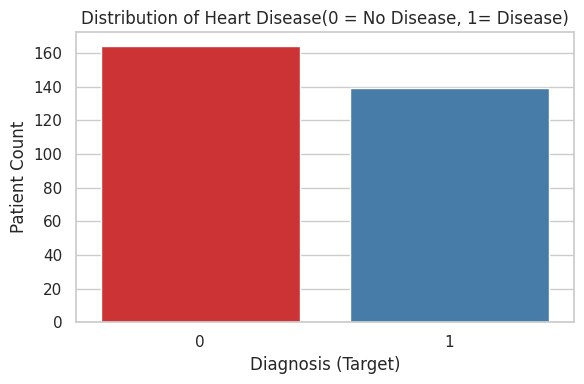

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='target' ,data=df, palette='Set1')
plt.title('Distribution of Heart Disease(0 = No Disease, 1= Disease)')
plt.xlabel('Diagnosis (Target)')
plt.ylabel('Patient Count')

plt.tight_layout()
plt.show()

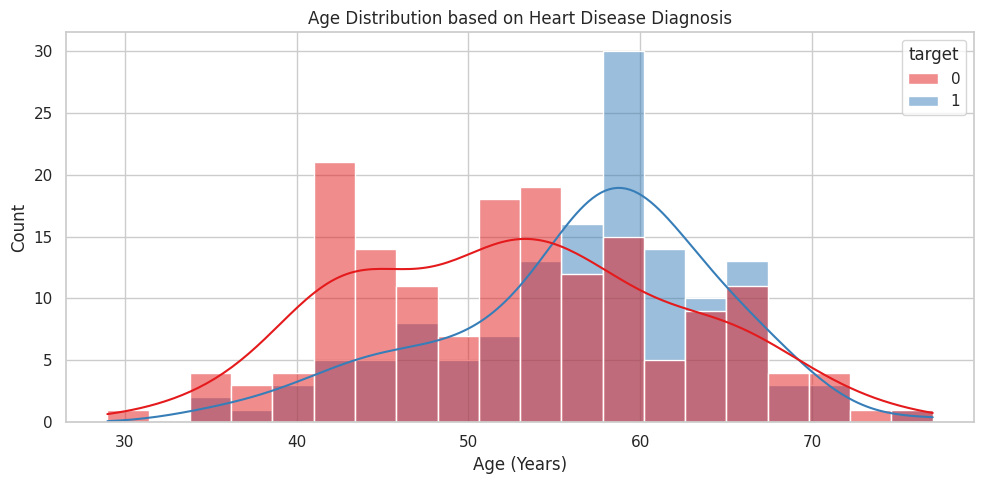

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True, palette='Set1')
plt.title('Age Distribution based on Heart Disease Diagnosis')
plt.xlabel('Age (Years)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

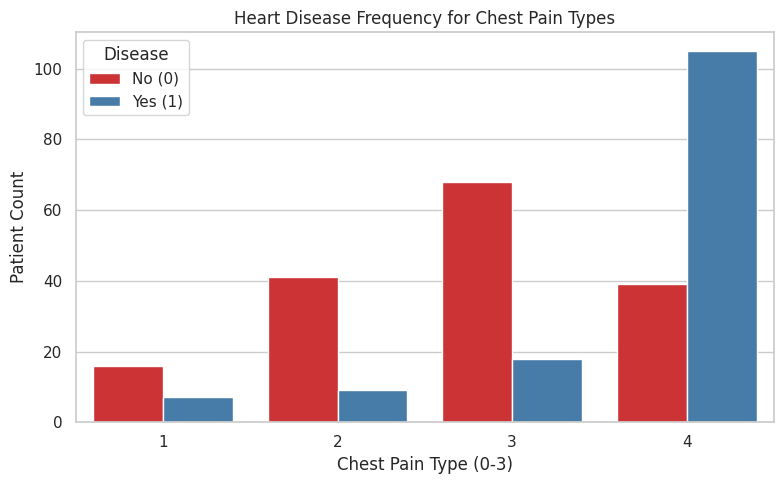

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='cp', hue='target', data=df, palette='Set1')
plt.title('Heart Disease Frequency for Chest Pain Types')
plt.xlabel('Chest Pain Type (0-3)')
plt.ylabel('Patient Count')
plt.legend(title='Disease', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

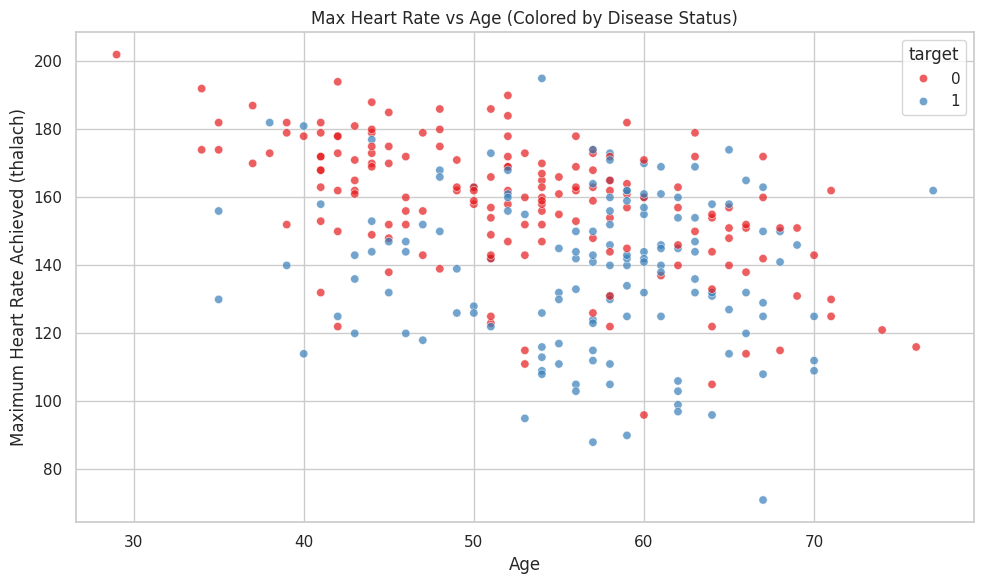

In [11]:
# Max Heart Rate (thalach) vs Age

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalach', hue='target', data=df, alpha=0.7, palette='Set1')
plt.title('Max Heart Rate vs Age (Colored by Disease Status)')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate Achieved (thalach)')

plt.tight_layout()
plt.show()

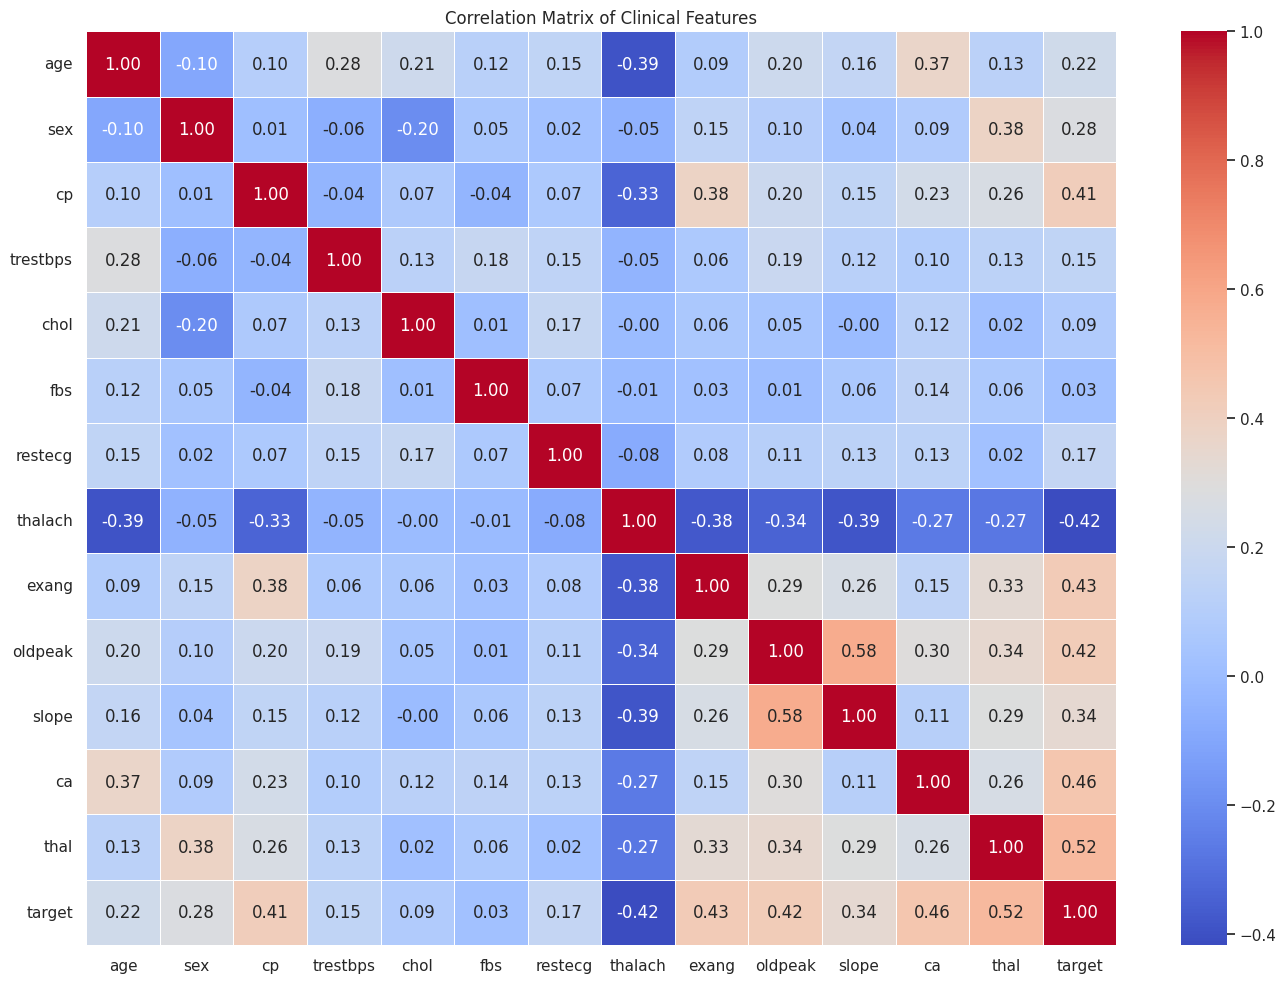

In [12]:
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5)
plt.title('Correlation Matrix of Clinical Features')

plt.tight_layout()
plt.show()

#5. Data Preprocessing (Encoding & Splitting)

In [13]:
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Train-Test Split (80/20)

x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

Training data shape: (242, 18)
Testing data shape: (61, 18)


#6. Model Development

In [17]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train Models
trained_models = {}
for name, model in models.items():
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(x_train_scaled, y_train)
    else:
        model.fit(x_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.
Gradient Boosting trained successfully.


#7. Hyperparameter Tuning

In [21]:
print("Tuning Random Forest Parameters......")

# Define parameter grid

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# Setup Grid Search

grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_grid = rf_params,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)

# Fit to training data

grid_search.fit(x_train, y_train)
best_rf_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Tuning Random Forest Parameters......
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}


#8. Model Evaluation

In [23]:

# Add tuned model to our dictionary for comparison

trained_models["Tuned Random Forest"] = best_rf_model
results = []

for name, model in trained_models.items():
    test_data = x_test_scaled if name in ["Logistic Regression", "SVM", "KNN"] else x_test

    y_pred = model.predict(test_data)
    y_proba = model.predict_proba(test_data)[:, 1]

    results.append({
    "Model": name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# Display results as a clean Dataframe
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
display(results_df.style.background_gradient(cmap='Blues'))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,KNN,0.918033,0.870968,0.964286,0.915254,0.951840
5,Gradient Boosting,0.885246,0.862069,0.892857,0.877193,0.939394
6,Tuned Random Forest,0.885246,0.862069,0.892857,0.877193,0.949134
2,Random Forest,0.868852,0.833333,0.892857,0.862069,0.951840
3,SVM,0.852459,0.851852,0.821429,0.836364,0.938312
0,Logistic Regression,0.819672,0.793103,0.821429,0.807018,0.939394
1,Decision Tree,0.803279,0.833333,0.714286,0.769231,0.796537


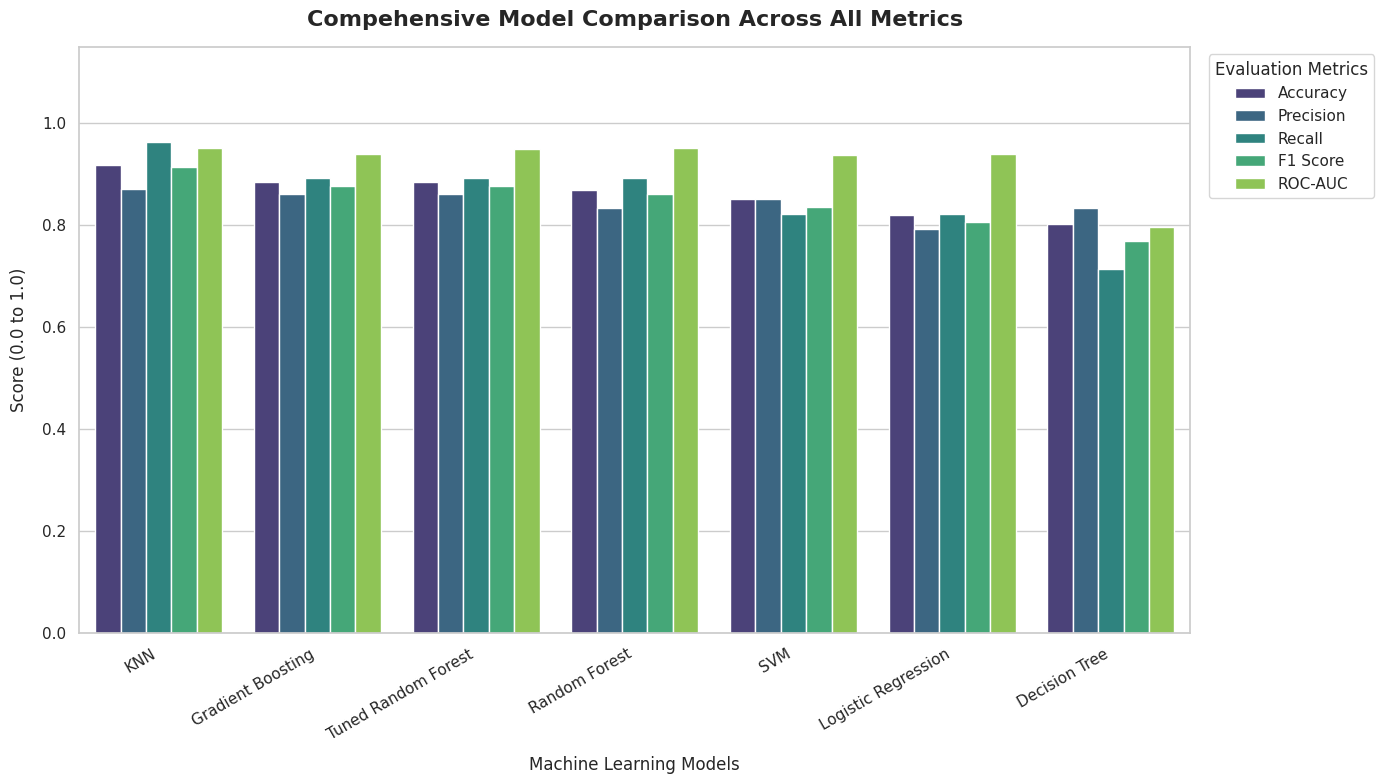

In [24]:
# Bar chart comparison

# Set the visual style
sns.set_theme(style="whitegrid")

# Melt the dataframe
df_melted = results_df.melt(id_vars = "Model",
                            var_name = "Metric",
                            value_name = "Score")

# Create the Bar Chart
plt.figure(figsize=(14, 8))
chart = sns.barplot(x = "Model",
                    y = "Score",
                    hue = "Metric",
                    data = df_melted,
                    palette = "viridis")

# Format the chart
plt.title("Compehensive Model Comparison Across All Metrics", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Machine Learning Models", fontsize=12, labelpad=10)
plt.ylabel("Score (0.0 to 1.0)", fontsize=12, labelpad=10)
plt.ylim(0, 1.15)
plt.legend(title="Evaluation Metrics", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

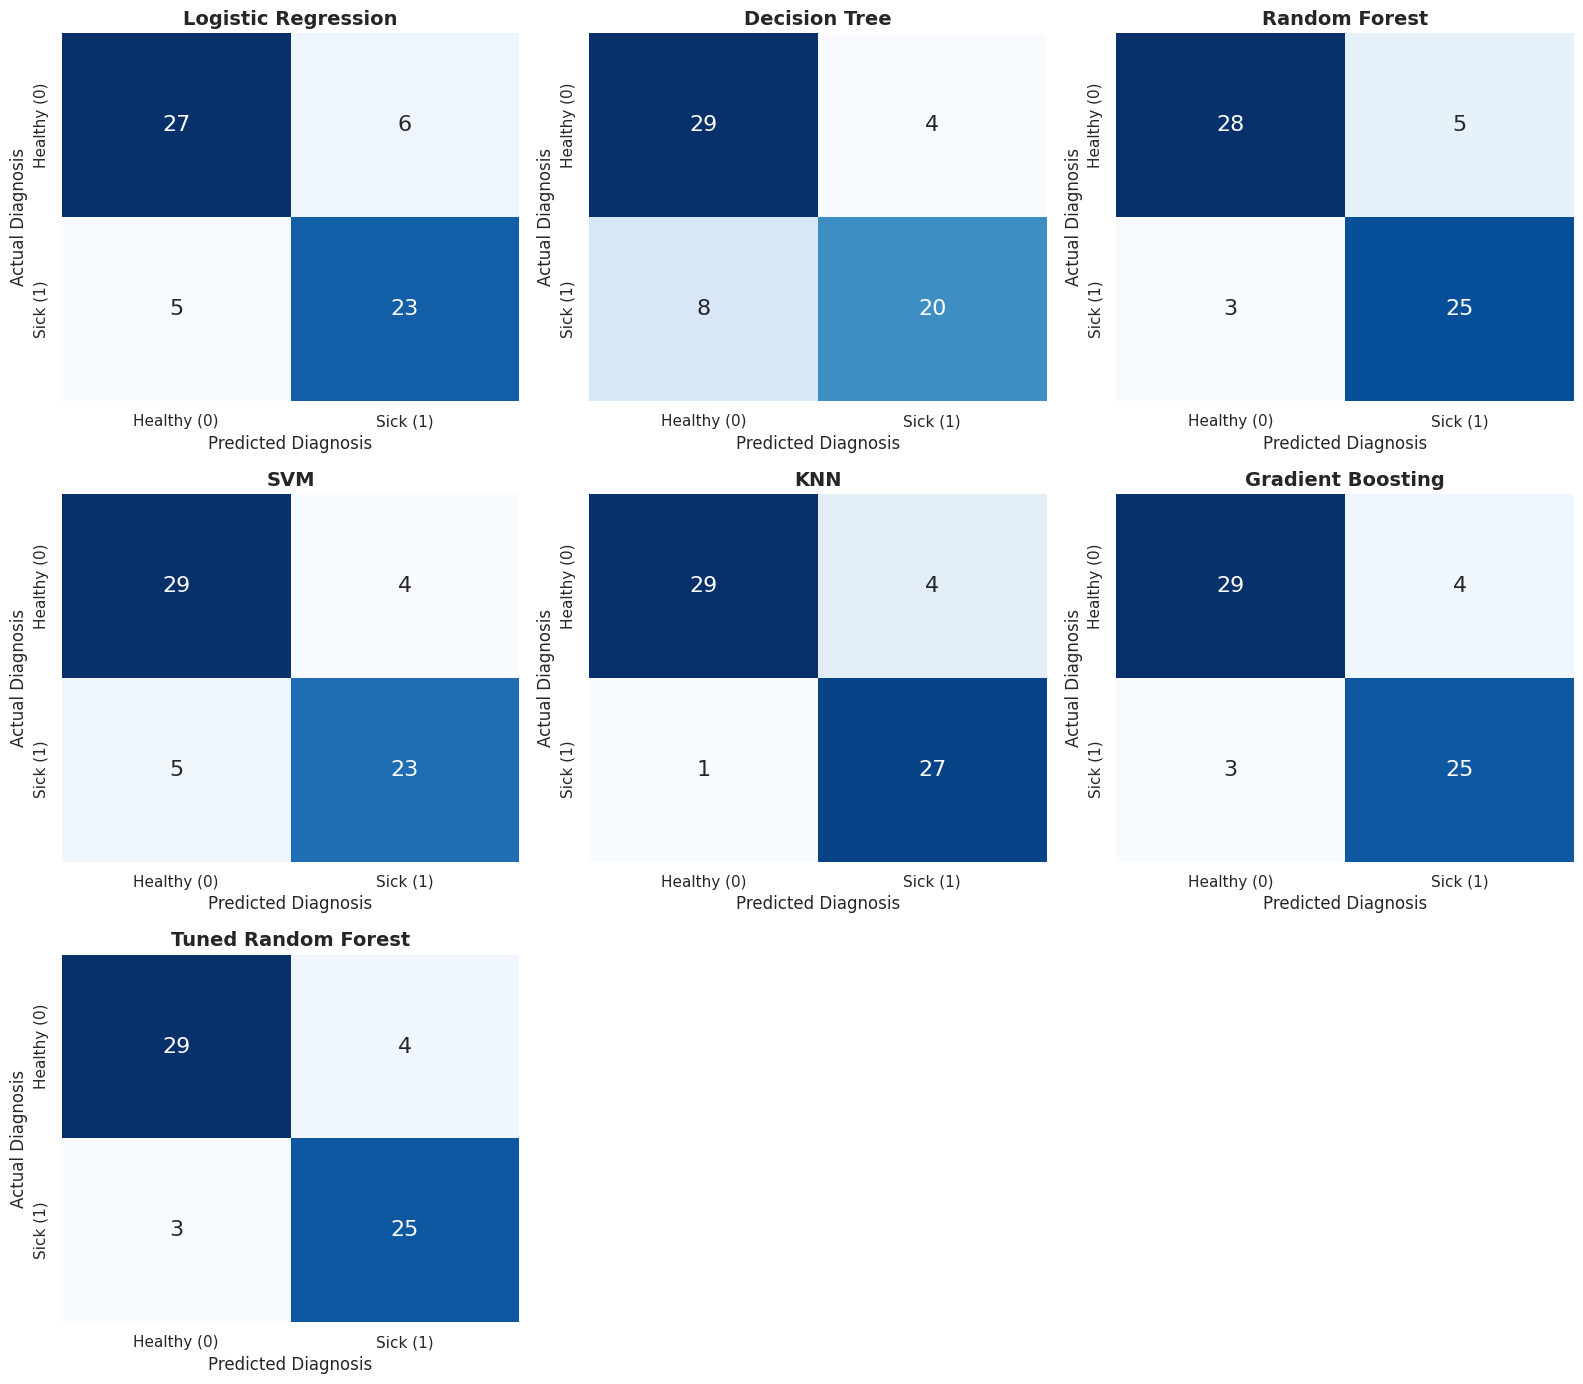

In [25]:
# Confusion Matrices - All Models

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    if name in ["Logistic Regression", "SVM", "KNN"]:
        test_data = x_test_scaled
    else:
        test_data = x_test

    y_pred = model.predict(test_data)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 16})

    axes[i].set_title(f"{name}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Predicted Diagnosis", fontsize=12)
    axes[i].set_ylabel("Actual Diagnosis", fontsize=12)

    axes[i].set_xticklabels(['Healthy (0)', 'Sick (1)'])
    axes[i].set_yticklabels(['Healthy (0)', 'Sick (1)'])

for j in range(len(trained_models), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#9. Key Risk Factor Insights

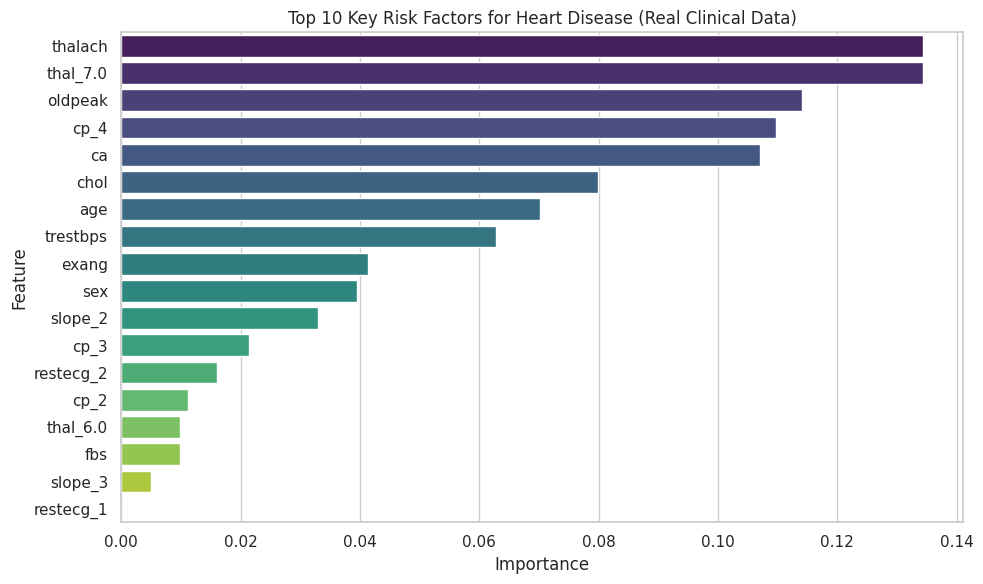

In [26]:
# Key Risk Factor Insights

importances = best_rf_model.feature_importances_
feature_names = x.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(18), palette='viridis')
plt.title('Top 10 Key Risk Factors for Heart Disease (Real Clinical Data)')

plt.tight_layout()
plt.show()

#10. Final Summary

In [27]:
print(" FINAL MODEL - Heart Disease Early Prediction ")
print()
print(f" Best Model    : Tuned Random Forest")
print(f" Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f" Precision     : {precision_score(y_test, y_pred):.4f}")
print(f" Recall        : {recall_score(y_test, y_pred):.4f}")
print(f" F1 Score      : {f1_score(y_test, y_pred):.4f}")
print(f" ROC-AUC       : {roc_auc_score(y_test, y_proba):.4f}")
print()

# Top 5 Insights
top5 = feat_imp_df['Feature'].head(5).tolist()
print("\nTOP RISK FACTORS IDENTIFIED:")
for i, f in enumerate(top5, 1):
    print(f" {i}. {f}")

 FINAL MODEL - Heart Disease Early Prediction 

 Best Model    : Tuned Random Forest
 Accuracy      : 0.8852
 Precision     : 0.8621
 Recall        : 0.8929
 F1 Score      : 0.8772
 ROC-AUC       : 0.9491


TOP RISK FACTORS IDENTIFIED:
 1. thalach
 2. thal_7.0
 3. oldpeak
 4. cp_4
 5. ca
